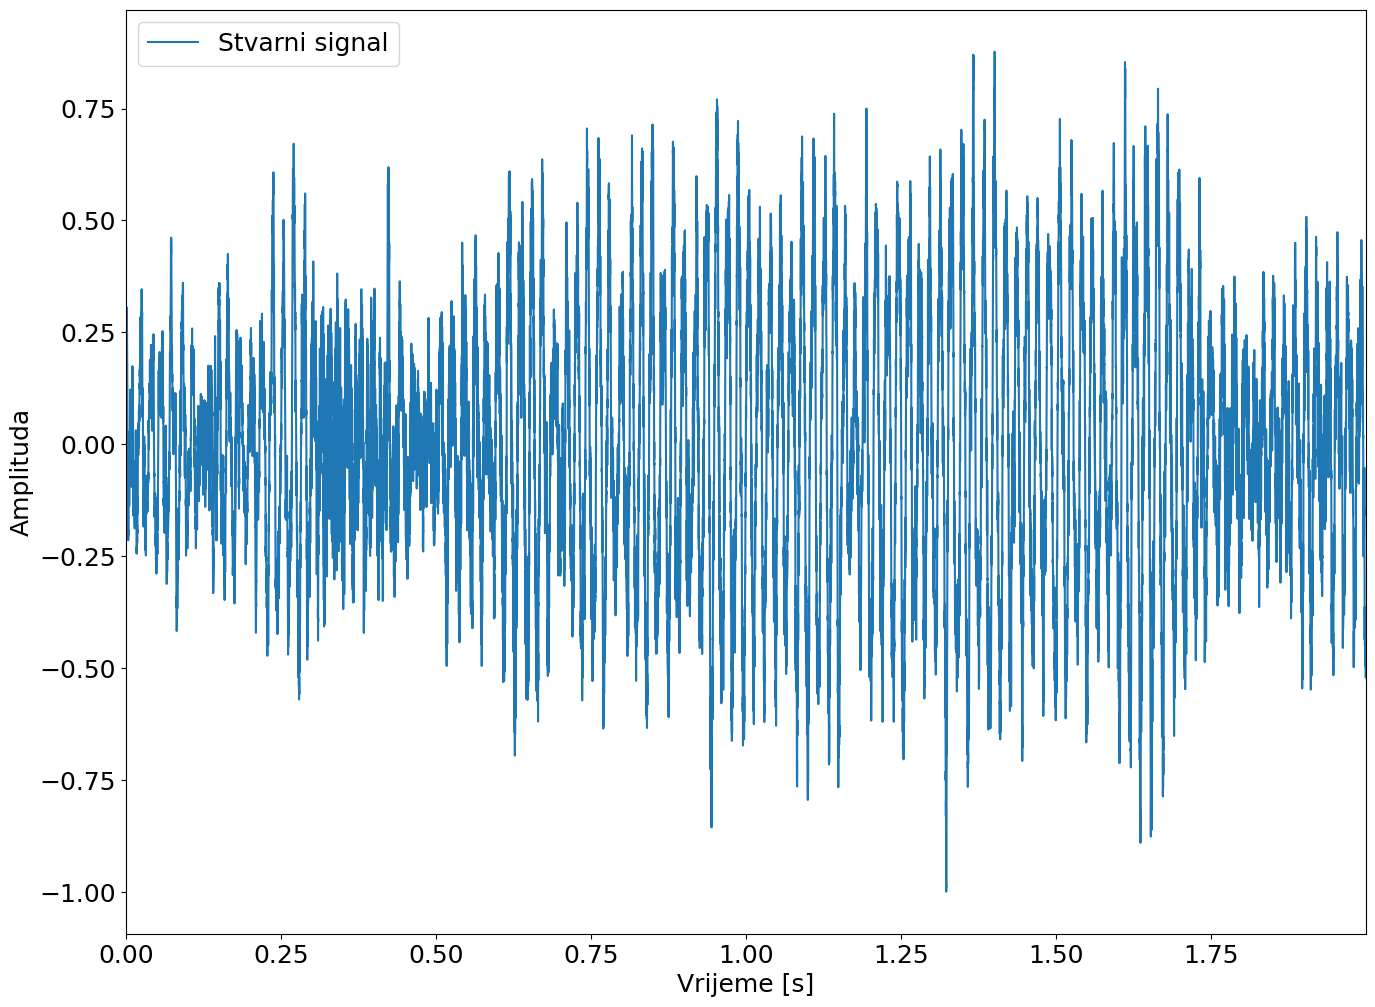

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio
from scipy.signal import butter, filtfilt

plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams.update({'font.size': 18})

# ucitavamo audio
file_path = "../data/all_sorted/BIC/00c20b00-2023-10-15_15-22-19.0-Rathdowne4_TJN_NoV_L1_3Lanes_Idling_stereo.wav"

fs, data = wavfile.read(file_path)  # fs = sample rate

# pretvaramo u mono ako je stereo
if len(data.shape) > 1:
    data = data.mean(axis=1)

# normalizacija signala
data = data / np.max(np.abs(data))

# uzimamo segment od 2 sekunde (to i jest duljina signala)
duration = 2
N = int(fs * duration)
f = data[:N]

# vremeska os
dt = 1 / fs
t = np.arange(0, len(f)) * dt

# (nema više f_clean jer je stvarni signal)
plt.plot(t, f, linewidth=1.5, label='Stvarni signal')
plt.xlim(t[0], t[-1])
plt.xlabel('Vrijeme [s]')
plt.ylabel('Amplituda')
plt.legend()
plt.show()



display(Audio(f, rate=fs))

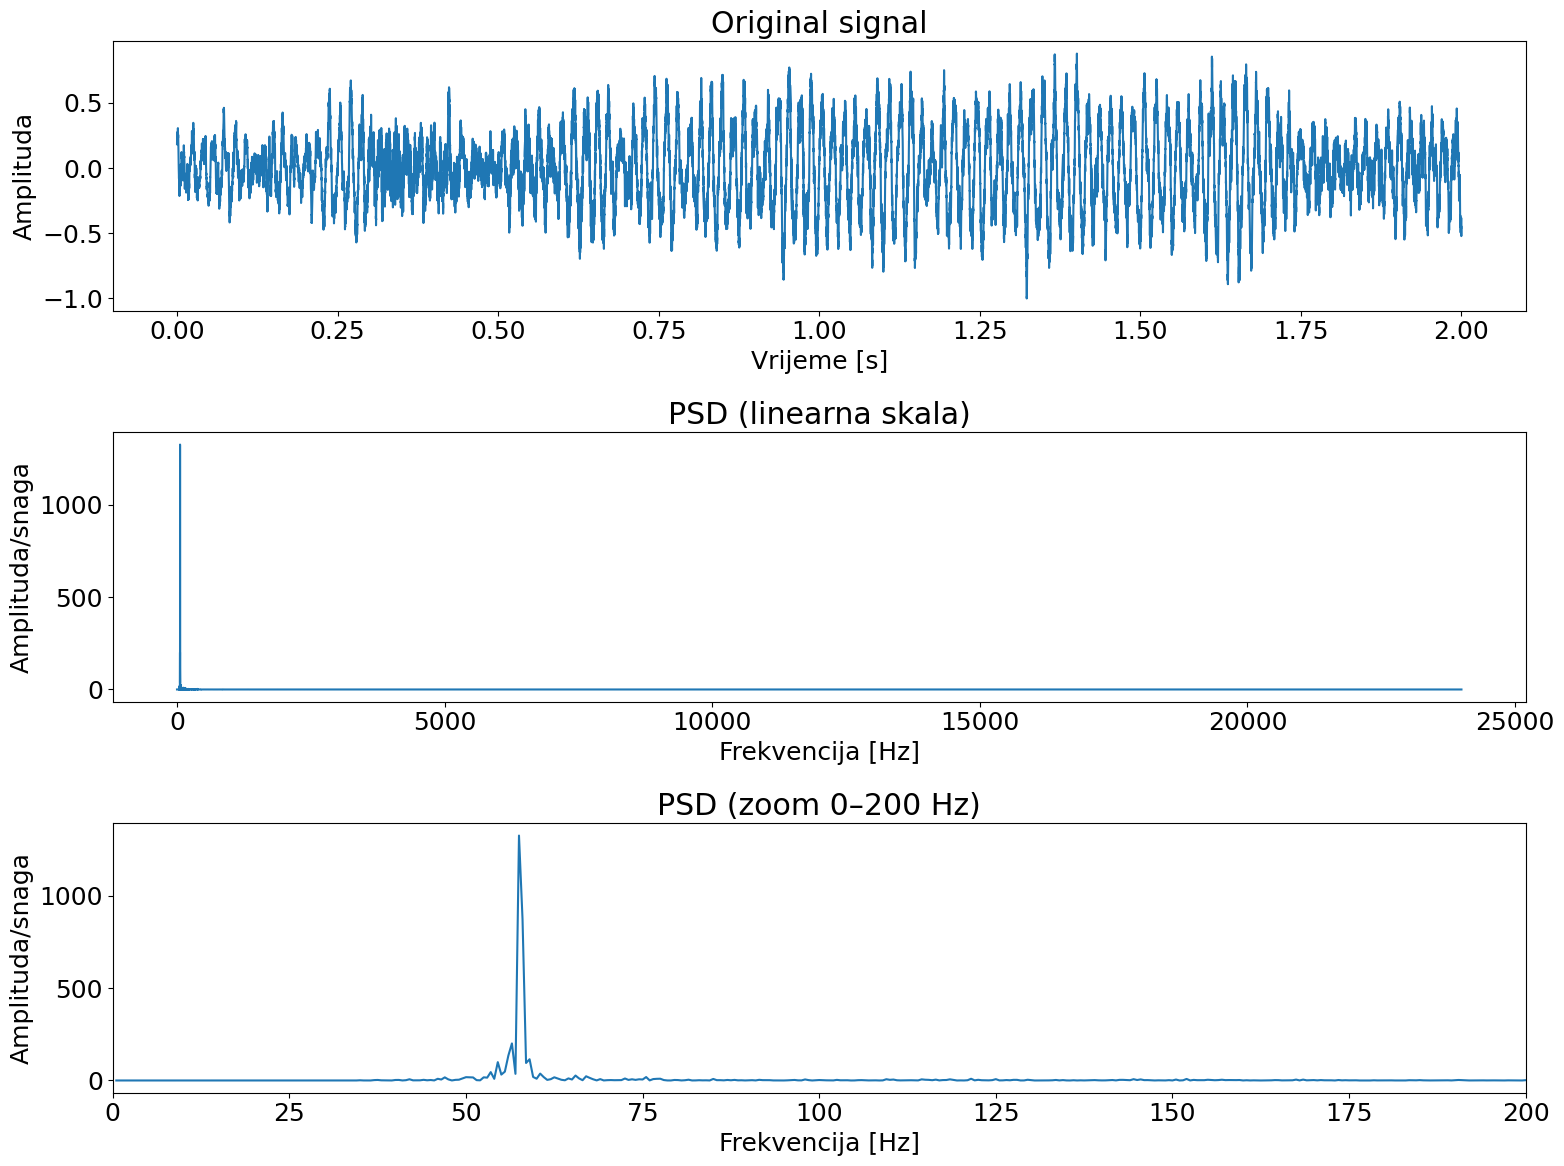

In [3]:
# FFT i PSD
n = len(f)
fhat = np.fft.fft(f)
PSD = np.abs(fhat)**2 / n

freq = np.fft.fftfreq(n, d=dt)
L = freq > 0

fig, axs = plt.subplots(3, 1)

# signal
axs[0].plot(t, f)
axs[0].set_title("Original signal")
axs[0].set_xlabel("Vrijeme [s]")
axs[0].set_ylabel("Amplituda")

# FFT (linearna skala)
axs[1].plot(freq[L], PSD[L])
axs[1].set_title("PSD (linearna skala)")
axs[1].set_xlabel("Frekvencija [Hz]")
axs[1].set_ylabel("Amplituda/snaga")

# FFT (log skala)
axs[2].plot(freq[L], PSD[L])
axs[2].set_xlim(0, 200)  # zoomirani gornji graf na 0-200 Hz
axs[2].set_title("PSD (zoom 0–200 Hz)")
axs[2].set_xlabel("Frekvencija [Hz]")
axs[2].set_ylabel("Amplituda/snaga")

plt.tight_layout()
plt.show()

In [6]:
threshold = np.max(PSD) * 0.05  # threshold za filtriranje (5% od maksimalne snage)
indices = PSD > threshold
fhat_clean = fhat * indices
PSDclean = PSD * indices
ffilt = np.fft.ifft(fhat_clean) # filtrirani fft
ffilt = np.real(ffilt)

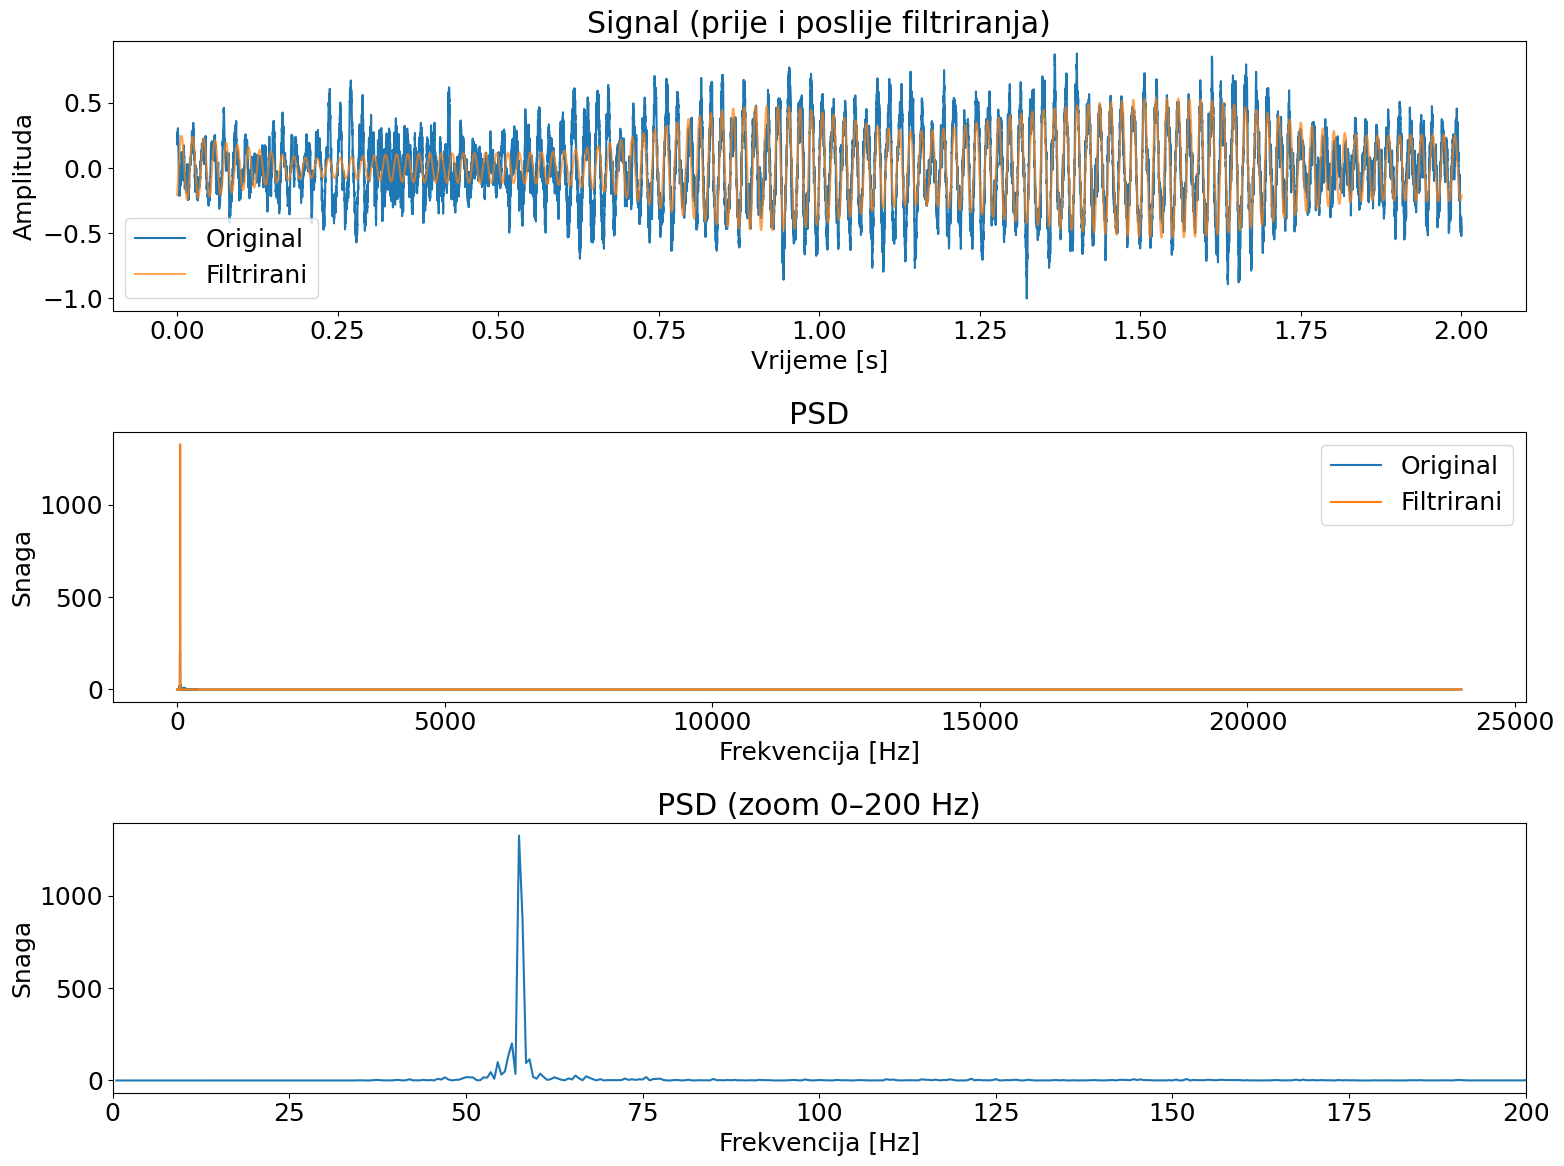

In [8]:
fig, axs = plt.subplots(3, 1)

# original signal
axs[0].plot(t, f, label='Original')
axs[0].plot(t, ffilt, label='Filtrirani', alpha=0.7)
axs[0].set_title("Signal (prije i poslije filtriranja)")
axs[0].set_xlabel("Vrijeme [s]")
axs[0].set_ylabel("Amplituda")
axs[0].legend()

# PSD
axs[1].plot(freq[L], PSD[L], label='Original')
axs[1].plot(freq[L], PSDclean[L], label='Filtrirani')
axs[1].set_title("PSD")
axs[1].set_xlabel("Frekvencija [Hz]")
axs[1].set_ylabel("Snaga")
axs[1].legend()

# zoom na niske frekvencije
axs[2].plot(freq[L], PSD[L])
axs[2].set_xlim(0, 200)
axs[2].set_title("PSD (zoom 0–200 Hz)")
axs[2].set_xlabel("Frekvencija [Hz]")
axs[2].set_ylabel("Snaga")

plt.tight_layout()
plt.show()

display(Audio(ffilt, rate=fs))

In [9]:
# high pass filter
cutoff = 1500

b, a = butter(4, cutoff/(fs/2), btype='high')
ffilt = filtfilt(b, a, f)

display(Audio(ffilt, rate=fs))

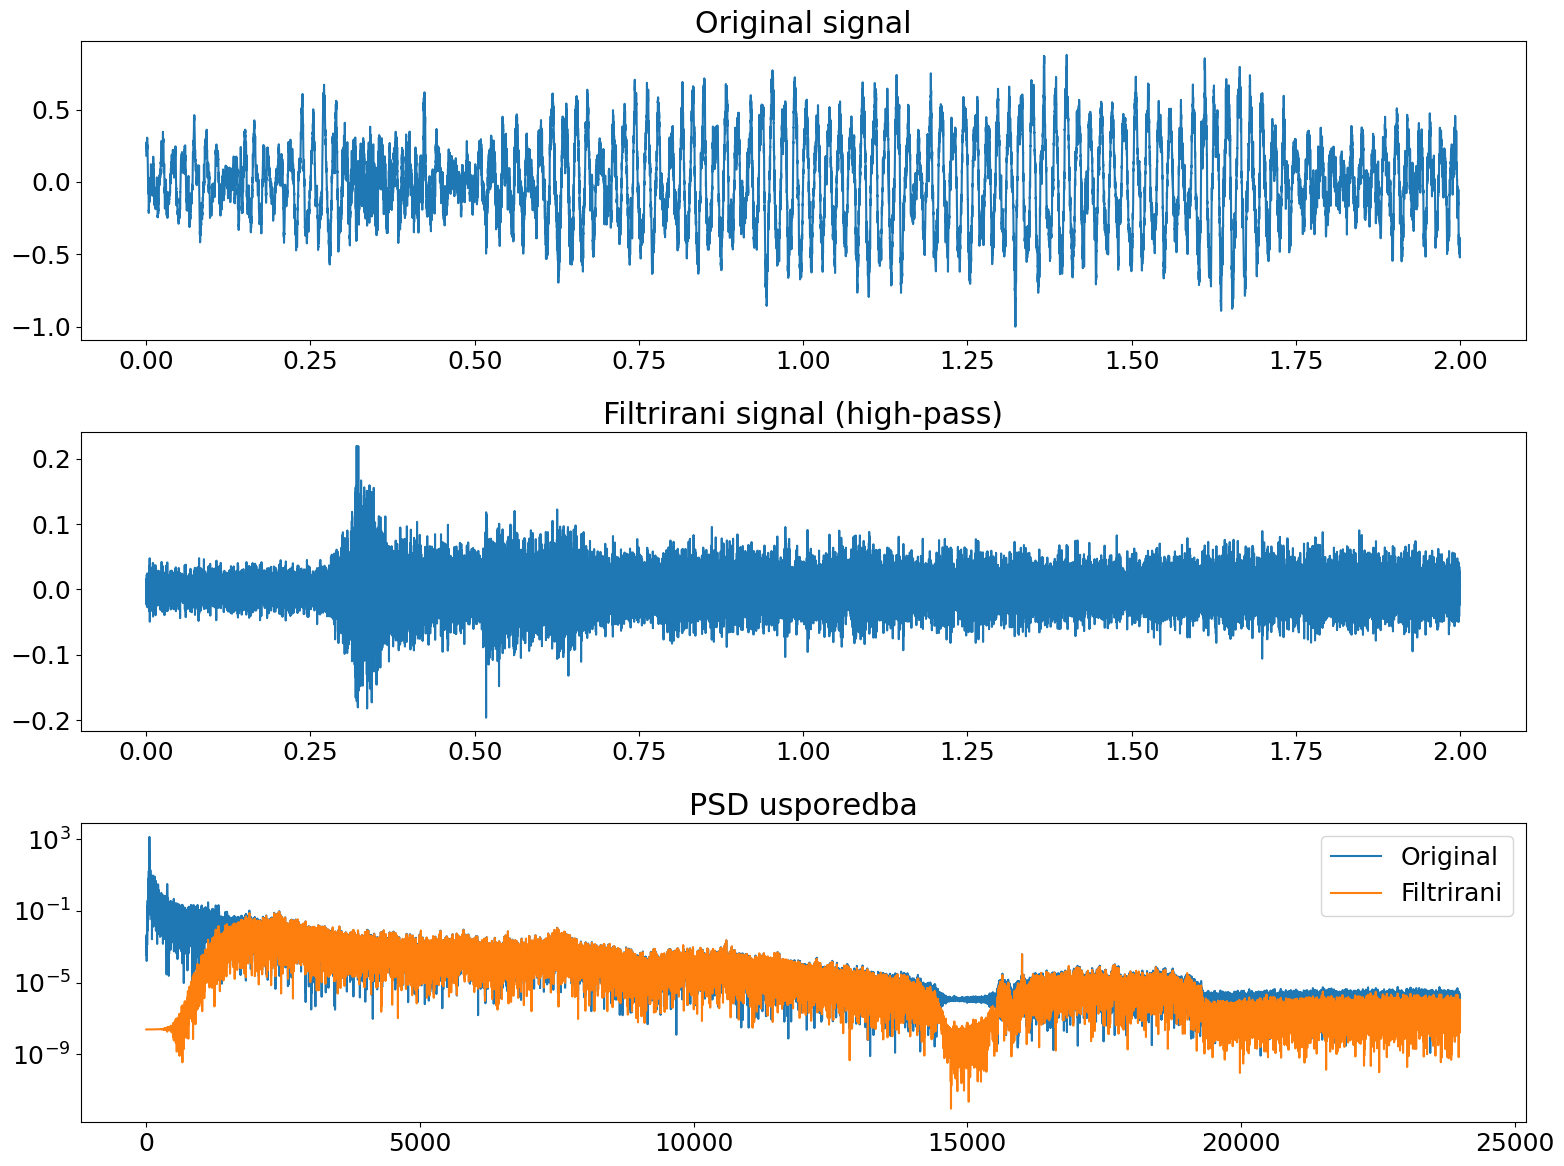

In [10]:
# FFT filtriranog
fhat_filt = np.fft.fft(ffilt)
PSD_filt = np.abs(fhat_filt)**2 / n

fig, axs = plt.subplots(3, 1)

# original
axs[0].plot(t, f)
axs[0].set_title("Original signal")

# filtrirani
axs[1].plot(t, ffilt)
axs[1].set_title("Filtrirani signal (high-pass)") # koje frekvencije postoje u signalu i koliko su jake

# PSD usporedba
axs[2].semilogy(freq[L], PSD[L], label="Original")
axs[2].semilogy(freq[L], PSD_filt[L], label="Filtrirani")
axs[2].set_title("PSD usporedba")
axs[2].legend()

plt.tight_layout()
plt.show()

In [11]:
from IPython.display import Audio
import os
from scipy.io.wavfile import write

output_dir = "output_audio"
os.makedirs(output_dir, exist_ok=True)

write(os.path.join(output_dir, "original.wav"), fs, f.astype(np.float32))
write(os.path.join(output_dir, "filtered.wav"), fs, ffilt.real.astype(np.float32))

# Original
display(Audio(f, rate=fs))

# Filtrirani (UZMI REALNI DIO!)
display(Audio(ffilt.real, rate=fs))

In [12]:
# Ekstrakcija feature-a

# dominantna frekvencija
dominant_freq = freq[L][np.argmax(PSD[L])]

# spectral centroid (težište)
centroid = np.sum(freq[L] * PSD[L]) / np.sum(PSD[L])

# bandwidth
bandwidth = np.sqrt(np.sum(((freq[L] - centroid)**2) * PSD[L]) / np.sum(PSD[L]))

# energija
energy = np.sum(f**2)

# zero crossing rate
zcr = np.mean(np.abs(np.diff(np.sign(f))))

import librosa

mfccs = librosa.feature.mfcc(y=f, sr=fs, n_mfcc=13)

print(f"Feature vector:", 
      f"Dominant frequency: {dominant_freq:.2f} Hz, "
      f"Spectral centroid: {centroid:.2f} Hz, "
      f"Bandwidth: {bandwidth:.2f} Hz, "
      f"Energy: {energy:.2f}, "
      f"ZCR: {zcr:.4f}, "
      f"MFCCs shape: {mfccs.shape}")

/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature vector: Dominant frequency: 57.50 Hz, Spectral centroid: 113.62 Hz, Bandwidth: 372.52 Hz, Energy: 8183.32, ZCR: 0.0281, MFCCs shape: (13, 188)


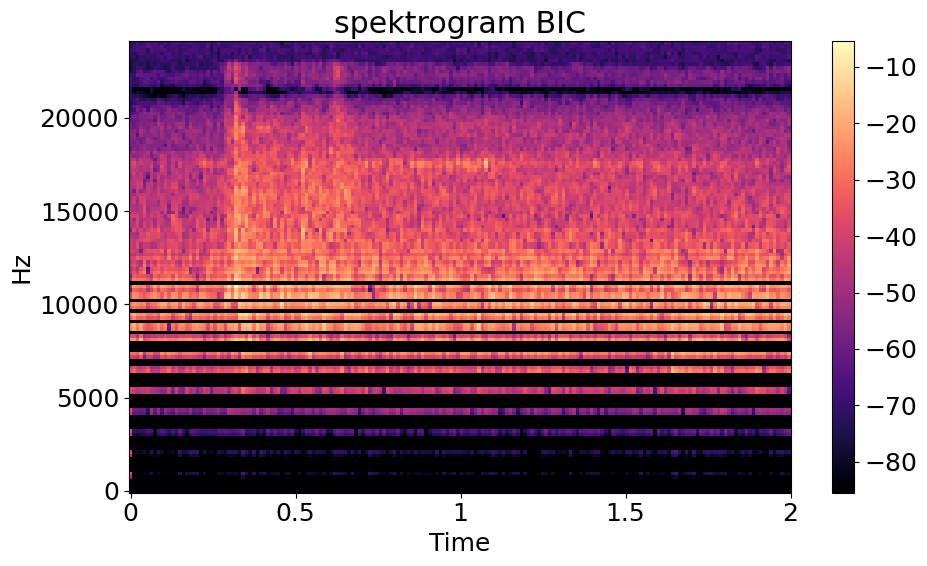

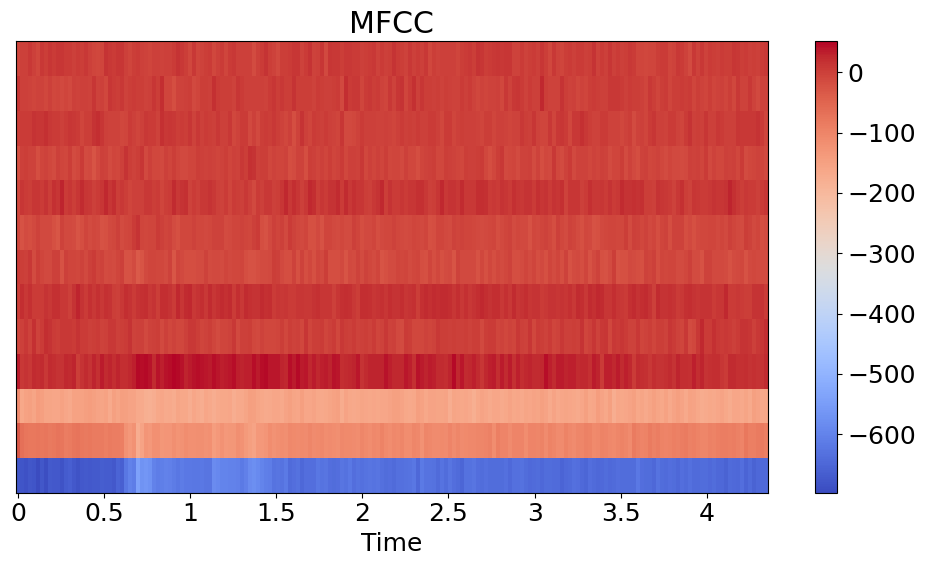

In [14]:
# Vizualizacija MFCC-a

import librosa
f_float = np.array(ffilt, dtype=np.float32)
sr = int(1/dt)  # Sampling rate jer dt=0.001 --> fs = 1000 HzS = librosa.feature.melspectrogram(y=f_float, sr=sr, n_fft=256)
S = librosa.feature.melspectrogram(y=f_float, sr=sr, n_fft=256)
mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=13)


plt.figure(figsize=(10,6))
librosa.display.specshow(librosa.power_to_db(S), sr=sr, x_axis='time', y_axis='hz')
plt.title("spektrogram BIC")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
librosa.display.specshow(mfccs, x_axis='time')
plt.title("MFCC")
plt.colorbar()
plt.tight_layout()
plt.show()